<a href="https://colab.research.google.com/github/staplesmaster/Tugas-Besar-IF2120-2025-2026---AyamAsapRempah/blob/main/Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas Besar IF2120 Probabilitas dan Statistika 2025/2026**

### Topik : **glaucoma**


K02 - Kelompok 22

Anggota Kelompok :
1. Reynard Nathanael - 13524103
2. Nicholas Luis Chandra - 13524105

## Inisialisasi Dependencies dan Load Data

Import required libraries

In [ ]:
# Sesuaikan dengan kebutuhan, uncomment yang perlu, hapus yang ga perlu, dan tambahkan jika perlu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

Load Data

In [ ]:
import gdown

# Ambil file_id dari link gdrive dataset
#https://drive.google.com/file/d/1Y5IkyggygLAozkg5kkngqec0oVaEJOod/view?usp=sharing
# https://drive.google.com/file/d/1UmbA42IocF4drZDSwcn2tF9zXgLZmhoM/view?usp=sharing -> file_id = 1UmbA42IocF4drZDSwcn2tF9zXgLZmhoM

# Kemudian, masukan file_id dengan template url berikut
# https://drive.google.com/uc?id={1fw2BsrXqUn3BUU5HdB5Tv5s2ybRI8iXz}

url = "https://drive.google.com/uc?id=1Y5IkyggygLAozkg5kkngqec0oVaEJOod"

output = "glaucoma.csv"
gdown.download(url, output, quiet=False)

glaucoma= pd.read_csv("glaucoma.csv")
glaucoma.info()

Downloading...
From: https://drive.google.com/uc?id=1Y5IkyggygLAozkg5kkngqec0oVaEJOod
To: /content/glaucoma.csv
100%|██████████| 3.38M/3.38M [00:00<00:00, 204MB/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Patient ID                                  10000 non-null  int64  
 1   Age                                         10000 non-null  int64  
 2   Gender                                      10000 non-null  object 
 3   Visual Acuity Measurements                  10000 non-null  object 
 4   Intraocular Pressure (IOP)                  10000 non-null  float64
 5   Cup-to-Disc Ratio (CDR)                     10000 non-null  float64
 6   Family History                              10000 non-null  object 
 7   Medical History                             7453 non-null   object 
 8   Medication Usage                            8769 non-null   object 
 9   Visual Field Test Results                   10000 non-null  object 
 10  Optical Coh

# Soal General

## Nomor 1
Menulis deskripsi statistika (Descriptive Statistics) dari semua kolom pada data.
- Data yang bersifat numerik dapat diberikan nilai mean, median, modus, standar deviasi, variansi, range, nilai minimum, maksimum, kuartil, IQR, skewness dan kurtosis.
- Data yang bersifat kategorikal dapat dicari unique values, dan proporsi nya.

### Implementasi Menggunakan Fungsi Buatan Sendiri

In [ ]:
numeric_cols = glaucoma.select_dtypes(include=np.number).columns
categorical_cols = glaucoma.select_dtypes(exclude=np.number).columns

data_numeric = glaucoma[numeric_cols]
data_categorical = glaucoma[categorical_cols]

print(data_categorical)

      Gender Visual Acuity Measurements Family History     Medical History  \
0       Male                 LogMAR 0.1             No            Diabetes   
1     Female                 LogMAR 0.1             No        Hypertension   
2     Female                      20/40             No        Hypertension   
3       Male                 LogMAR 0.0             No                 NaN   
4       Male                 LogMAR 0.1             No            Diabetes   
...      ...                        ...            ...                 ...   
9995  Female                 LogMAR 0.1             No                 NaN   
9996    Male                 LogMAR 0.0             No            Diabetes   
9997  Female                      20/40            Yes            Diabetes   
9998    Male                 LogMAR 0.1             No  Glaucoma in family   
9999    Male                 LogMAR 0.0             No            Diabetes   

                                       Medication Usage  \
0   

Data Numerik

In [ ]:

# Tulis kode deskripsi statistika data numerik kalian disini

def merge(arr, left, mid, right):
    n1 = mid - left + 1
    n2 = right - mid

    L = [0] * n1
    R = [0] * n2

    for i in range(n1):
        L[i] = arr[left + i]
    for j in range(n2):
        R[j] = arr[mid + 1 + j]

    i = 0
    j = 0
    k = left

    while i < n1 and j < n2:
        if L[i] <= R[j]:
            arr[k] = L[i]
            i += 1
        else:
            arr[k] = R[j]
            j += 1
        k += 1


    while i < n1:
        arr[k] = L[i]
        i += 1
        k += 1

    while j < n2:
        arr[k] = R[j]
        j += 1
        k += 1

def mergeSort(arr, left, right):
    if left < right:
        mid = (left + right) // 2

        mergeSort(arr, left, mid)
        mergeSort(arr, mid + 1, right)
        merge(arr, left, mid, right)

def mean_manual(data):
  sum = 0
  i = 0
  for row in data:
    sum += row
    i += 1
  return sum/i

def median_manual(data):
  temp = data.copy()
  length = len(temp)
  mergeSort(temp, 0, length - 1)
  if (length % 2 == 0):
    n1 = length // 2
    n2 = n1 + 1
    return (temp[n1] + temp [n2]) / 2
  else:
    return temp[length / 2]

def modus_manual(data):
  freq = {}
  for item in data:
    if (item in freq):
      freq[item] += 1
    else:
      freq[item] = 1

  max = 0
  result = 0
  for item in freq:
    if (freq[item] > max):
      max = freq[item]
      result = item
  return result

def variansi_manual(data):
  meanTemp = mean_manual(data)
  length = len(data)
  sum = 0
  for item in data:
    sum += (item - meanTemp)**2

  return (sum/(length - 1))

def standar_deviation_manual(data):
  variance = variansi_manual(data)
  return np.sqrt(variance)


def maksimum_manual(data):
  max = 0
  for item in data:
    if (item > max):
      max = item
  return max

def minimum_manual(data):
  min = maksimum_manual(data)
  for item in data:
    if (item < min):
      min = item
  return min


def range_manual(data):
  return maksimum_manual(data) - minimum_manual(data)

def q1_manual(data):
  temp = data.copy()
  length = len(data)
  mergeSort(temp, 0, length - 1)
  if (length % 4 == 0):
    n1 = length // 4
    n2 = n1 + 1
    return (temp[n1] + temp [n2]) / 2
  else:
    return temp[length / 4]

def q3_manual(data):
  temp = data.copy()
  length = len(data)
  mergeSort(temp, 0, length - 1)
  n1 = (length * 3)//4
  n2 = n1 + 1
  return (temp[n1] + temp [n2]) / 2


def iqr_manual(data):
  q3 = q3_manual(data)
  q1 = q1_manual(data)
  return (q3-q1)

def skewness_manual(data):
  meantemp = mean_manual(data)
  stdtemp = standar_deviation_manual(data)
  length = len(data)
  sum = 0

  for item in data:
    sum += ((item - meantemp)/stdtemp)**3
  return sum / length

def kurtosis_manual(data):
  meantemp = mean_manual(data)
  stdtemp = standar_deviation_manual(data)
  length = len(data)
  sum = 0

  for item in data:
    sum += ((item - meantemp)/stdtemp)**4
  return (sum / length) - 3


numerical_stats_manual = []


for col in numeric_cols:
  d = glaucoma[col]
  stat = {
    'Column': col,
    'Mean': mean_manual(d),
    'Median': median_manual(d),
    'Mode': modus_manual(d),
    'Min': minimum_manual(d),
    'Max': maksimum_manual(d),
    'Range': range_manual(d),
    'Variance': variansi_manual(d),
    'Std Dev': standar_deviation_manual(d),
    'Q1 (25%)': q1_manual(d),
    'Q3 (75%)': q3_manual(d),
    'IQR': iqr_manual(d),
    'Skewness': skewness_manual(d),
    'Kurtosis': kurtosis_manual(d)
  }
  numerical_stats_manual.append(stat)

data_numerical_stats_manual = pd.DataFrame(numerical_stats_manual).set_index('Column')
print(data_numerical_stats_manual)

                                    Mean    Median      Mode     Min  \
Column                                                                 
Patient ID                  50002.168800  50094.00  62431.00    4.00   
Age                            53.872200     54.00     18.00   18.00   
Intraocular Pressure (IOP)     17.507527     17.49     21.65   10.00   
Cup-to-Disc Ratio (CDR)         0.548437      0.55      0.66    0.30   
Pachymetry                    549.733974    549.35    547.89  500.01   

                                 Max     Range      Variance       Std Dev  \
Column                                                                       
Patient ID                  99992.00  99988.00  8.375135e+08  28939.824980   
Age                            90.00     72.00  4.463739e+02     21.127563   
Intraocular Pressure (IOP)     25.00     15.00  1.897562e+01      4.356101   
Cup-to-Disc Ratio (CDR)         0.80      0.50  2.082995e-02      0.144326   
Pachymetry                 

Data Kategorikal

In [ ]:
# Tulis kode deskripsi statistika data kategorikal kalian disini
def nilaiunik_manual(data):
    unik = []
    for item in data:
        if item not in unik:
            unik.append(item)
    return unik

def frekuensi_manual(data):
    frek = {}
    for item in data:
        if item in frek:
            frek[item] += 1
        else:
            frek[item] = 1
    return frek

def proporsi_manual(data):
    frek = frekuensi_manual(data)
    total = len(data)
    return {item: count / total for item, count in frek.items()}

categorical_stats_manual = []

for col in categorical_cols:
    d = glaucoma[col]
    stat = {
        'Column': col,
        'Unique values': nilaiunik_manual(d),
        'Proporsi': proporsi_manual(d),
    }
    categorical_stats_manual.append(stat)

data_categorical_stats_manual = pd.DataFrame(categorical_stats_manual).set_index('Column')
data_categorical_stats_manual.head()


,Unique values,Proporsi
Column,,
Gender,"[Male, Female]","{'Male': 0.5029, 'Female': 0.4971}"
Visual Acuity Measurements,"[LogMAR 0.1, 20/40, LogMAR 0.0, 20/20]","{'LogMAR 0.1': 0.2518, '20/40': 0.2442, 'LogMA..."
Family History,"[No, Yes]","{'No': 0.5025, 'Yes': 0.4975}"
Medical History,"[Diabetes, Hypertension, nan, Glaucoma in family]","{'Diabetes': 0.2471, 'Hypertension': 0.2491, n..."
Medication Usage,"[Amoxicillin, Lisinopril, Omeprazole, Atorvast...","{'Amoxicillin, Lisinopril, Omeprazole, Atorvas..."


### Implementasi Menggunakan Library

#### Data Numerik

In [ ]:
# Tulis kode deskripsi statistika data numerik kalian disini
numerical_stats_library = []
for col in numeric_cols:
    d = glaucoma[col]
    stats = {
        'Kategori': col,
        'Mean': d.mean(),
        'Median': d.median(),
        'Mode': d.round(1).mode()[0], # Ambil modus pertama jika ada banyak
        'Min': d.min(),
        'Max': d.max(),
        'Range': d.max() - d.min(),
        'Variance': d.var(),
        'Std Dev': d.std(),
        'Q1 (25%)': d.quantile(0.25),
        'Q3 (75%)': d.quantile(0.75),
        'IQR': d.quantile(0.75) - d.quantile(0.25),
        'Skewness': d.skew(),
        'Kurtosis': d.kurt()
    }

    numerical_stats_library.append(stats)
data_numerical_stats_library = pd.DataFrame(numerical_stats_library).set_index('Kategori')
data_numerical_stats_library.head()

,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev,Q1 (25%),Q3 (75%),IQR,Skewness,Kurtosis
Kategori,,,,,,,,,,,,,
Patient ID,50002.168800,50091.500,4.0,4.00,99992.00,99988.00,8.375135e+08,28939.824980,24660.25,74829.2500,50169.0000,0.001186,-1.204538
Age,53.872200,54.000,18.0,18.00,90.00,72.00,4.463739e+02,21.127563,36.00,72.0000,36.0000,0.006300,-1.194722
Intraocular Pressure (IOP),17.507527,17.485,24.4,10.00,25.00,15.00,1.897562e+01,4.356101,13.76,21.3000,7.5400,0.005053,-1.204259
Cup-to-Disc Ratio (CDR),0.548437,0.550,0.4,0.30,0.80,0.50,2.082995e-02,0.144326,0.42,0.6700,0.2500,0.016382,-1.195783
Pachymetry,549.733974,549.335,542.8,500.01,599.99,99.98,8.353684e+02,28.902741,524.59,574.9725,50.3825,0.004848,-1.203479


#### Data Kategorikal

In [ ]:
# Tulis kode deskripsi statistika data kategorikal kalian disini

categorical_stats_library = []
for col in categorical_cols:
    d = glaucoma[col]
    stats = {
        'Kategori': col,
        'Unique values' : d.unique(),
        'Proporsi' : d.value_counts(normalize=True).to_dict()

    }

    categorical_stats_library.append(stats)
data_categorical_stats_library = pd.DataFrame(categorical_stats_library).set_index('Kategori')
data_categorical_stats_library.head()


,Unique values,Proporsi
Kategori,,
Gender,"[Male, Female]","{'Male': 0.5029, 'Female': 0.4971}"
Visual Acuity Measurements,"[LogMAR 0.1, 20/40, LogMAR 0.0, 20/20]","{'LogMAR 0.0': 0.2551, 'LogMAR 0.1': 0.2518, '..."
Family History,"[No, Yes]","{'No': 0.5025, 'Yes': 0.4975}"
Medical History,"[Diabetes, Hypertension, nan, Glaucoma in family]","{'Hypertension': 0.33422782772038107, 'Glaucom..."
Medication Usage,"[Amoxicillin, Lisinopril, Omeprazole, Atorvast...","{'Amoxicillin': 0.02531645569620253, 'Metformi..."


#### Perbandingan Hasil Fungsi Buatan Sendiri dengan Library

Jelaskan apakah implementasi deskripsi statistika dengan menggunakan fungsi buatan sendiri dan menggunakan library menghasilkan nilai yang sama?

## Nomor 2
Apakah pada data tersebut terdapat outlier? Jika ya, dapatkah anda menanganinya? Jelaskan apa yang umumnya dilakukan untuk menangani outlier.

Penjelasan:

Untuk menangani outlier, hal yang umumnya dilakukan adalah


*   Menghitung Batas Atas dan Batas Bawah (Jarak antara Kuartil 1 dan Kuartil 3), untuk memastikan jika ada data yang berada di luar batas atas maupun batas bawah, maka data tersebut sudah pasti termasuk ke dalam outlier.



In [ ]:
outlier_report = []

for col in numeric_cols:
    if col == 'Patient ID':
        continue

    d_list = glaucoma[col].tolist()

    q1 = q1_manual(d_list)
    q3 = q3_manual(d_list)
    iqr = iqr_manual(d_list)

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = [x for x in d_list if x < lower_bound or x > upper_bound]
    total_outliers = len(outliers)

    stat = {
        'Column': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Total Outliers': total_outliers,
    }
    outlier_report.append(stat)

df_outlier_analysis = pd.DataFrame(outlier_report).set_index('Column')

print("Tabel Analisis Outlier:")
display(df_outlier_analysis)




Tabel Analisis Outlier:


,Q1,Q3,IQR,Lower Bound,Upper Bound,Total Outliers
Column,,,,,,
Age,36.000,72.00,36.000,-18.0000,126.0000,0
Intraocular Pressure (IOP),13.760,21.30,7.540,2.4500,32.6100,0
Cup-to-Disc Ratio (CDR),0.420,0.67,0.250,0.0450,1.0450,0
Pachymetry,524.595,574.98,50.385,449.0175,650.5575,0


### Penanganan Outlier

Jelaskan metode yang Anda gunakan untuk menangani outlier pada bagian ini, beserta alasan pemilihan metode tersebut.

Penjelasan:

Dikarenakan dataset yang kami kerjakan adalah glaucoma, kami merasa penanganan outliers menggunakan metode capping merupakan pilihan terbaik. Penanganan Outlier menggunakan metode capping membantu mengubah data dalam dataset glaucoma yang berada di luar batas atas (upper_bound) ataupun batas bawah (lower_bound) menjadi batas atas atau batas bawah, sehingga tingkat perbedaan data dalam dataset menjadi lebih kecil.

In [ ]:
numeric_cols = glaucoma.select_dtypes(include=np.number).columns

laporan_capping = []

for col in numeric_cols:
    if col == 'Patient ID':
        continue

    d_list = glaucoma[col].tolist()

    q1 = q1_manual(d_list)
    q3 = q3_manual(d_list)
    iqr = iqr_manual(d_list)

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    above_upper = len([x for x in d_list if x < lower_bound])
    below_lower = len([x for x in d_list if x > upper_bound])
    change = above_upper + below_lower
    total_changed = (change / len(d_list)) * 100

    def capping(value):
        if value > upper_bound:
            return upper_bound
        elif value < lower_bound:
            return lower_bound
        else:
            return value

    new_values = [capping(x) for x in d_list]

    glaucoma[col] = new_values

    stat = {
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Diubah (Menjadi Batas Bawah)': above_upper,
        'Diubah (Menjadi Batas Atas)': below_lower,
        'Total Diubah': change,
        '% Data Berubah': f"{total_changed:.2f}%"
    }
    laporan_capping.append(stat)

df_laporan = pd.DataFrame(laporan_capping).set_index('Column')

print(f"Total Baris Data: {len(glaucoma)}")
display(df_laporan)

print("\n=== Statistik Data Baru ===")
cols_to_show = [c for c in numeric_cols if c != 'Patient ID']
display(glaucoma[cols_to_show].describe())

Total Baris Data: 10000


,Lower Bound,Upper Bound,Diubah (Menjadi Batas Bawah),Diubah (Menjadi Batas Atas),Total Diubah,% Data Berubah
Column,,,,,,
Age,-18.0000,126.0000,0,0,0,0.00%
Intraocular Pressure (IOP),2.4500,32.6100,0,0,0,0.00%
Cup-to-Disc Ratio (CDR),0.0450,1.0450,0,0,0,0.00%
Pachymetry,449.0175,650.5575,0,0,0,0.00%



=== Statistik Data Baru ===


,Age,Intraocular Pressure (IOP),Cup-to-Disc Ratio (CDR),Pachymetry
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.872200,17.507527,0.548437,549.733974
std,21.127563,4.356101,0.144326,28.902741
min,18.000000,10.000000,0.300000,500.010000
25%,36.000000,13.760000,0.420000,524.590000
50%,54.000000,17.485000,0.550000,549.335000
75%,72.000000,21.300000,0.670000,574.972500
max,90.000000,25.000000,0.800000,599.990000


## Nomor 3
Membuat Visualisasi plot distribusi. Berikan uraian penjelasan kondisi setiap kolom berdasarkan kedua plot tersebut. Jika numerik dapat dibuat dalam bentuk histogram dan box plot, dan jika kategorikal dengan histogram.

In [ ]:
def visualize_boxplot(data, columns, vert=True, title_prefix="Box Plot"):
    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        if col not in data.columns:
            continue
        plt.figure(figsize=(6, 5)) # Ukuran canvas

        box = plt.boxplot(data[col], vert=vert, patch_artist=True)

        for patch in box['boxes']:
            patch.set_facecolor("#EEC50E")
        for element in ['whiskers', 'caps', 'medians']:
            plt.setp(box[element], color='#1C2340', linewidth=2)

        plt.title(f'{title_prefix}: {col}', fontweight='bold')

        if vert:
            plt.ylabel('Nilai')
            plt.xticks([])
        else:
            plt.xlabel('Nilai')
            plt.yticks([])

        plt.grid(linestyle='--', alpha=0.5)
        plt.show()

def visualize_histogram(data, columns, bins=30, show_stats=True):
    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        if col not in data.columns:
            continue

        d = data[col]

        plt.figure(figsize=(8, 5))

        plt.hist(d, bins=bins, color="#37D659", edgecolor='#1C2340', alpha=0.7)

        if show_stats:
            mean_val = d.mean()
            median_val = d.median()
            plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
            plt.axvline(median_val, color='blue', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')
            plt.legend()

        plt.title(f'Visualisasi Diagram: {col}', fontweight='bold')
        plt.xlabel('Nilai')
        plt.ylabel('Frekuensi')
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.show()

def visualize_categorical(data, columns):
    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        if col not in data.columns:
            print(f"Kolom '{col}' tidak ditemukan.")
            continue

        d = data[col]

        # Pastikan ini benar-benar kategorikal / string
        if pd.api.types.is_numeric_dtype(d):
            print(f"Kolom '{col}' numerik — gunakan histogram/boxplot.")
            continue

        counts = d.value_counts()

        plt.figure(figsize=(7, 5))
        plt.bar(counts.index, counts.values,
                color="#37D659", edgecolor="#1C2340")

        plt.title(f"Bar Chart (Kategorikal): {col}", fontweight='bold')
        plt.xlabel("Kategori")
        plt.ylabel("Frekuensi")
        plt.grid(axis='y', linestyle='--', alpha=0.3)

        # rotate jika label panjang
        plt.xticks(rotation=45)
        plt.show()


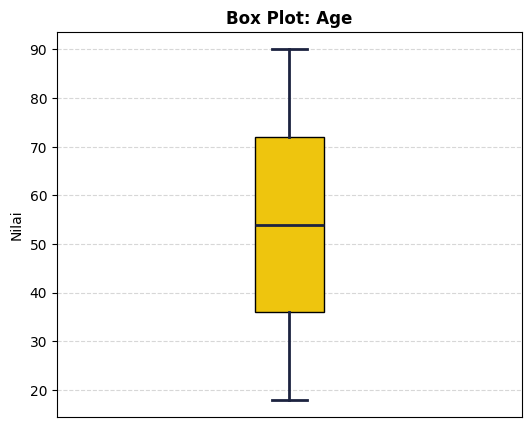

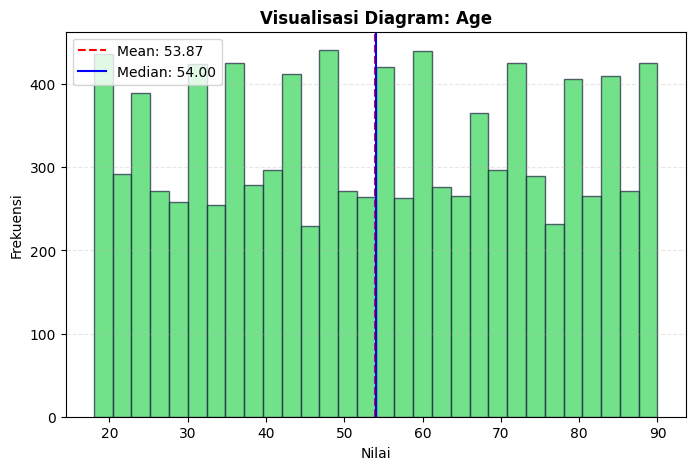

In [ ]:
visualize_boxplot(glaucoma, ['Age'])
visualize_histogram(glaucoma, ['Age'])

### Kolom Age

Berdasarkan hasil visualisasi, didapatkan bahwa kolom 'Age' memiliki karakteristik sebagai berikut:
* Nilai Minimum = 18
* Nilai Maksimum = 90
* Q1 = 36
* Q2 = 54
* Q3 = 72

Hasil visualisasi box-plot menunjukkan bahwa umur pasien yang ada di dalam dataset glaucoma berada di rentang umur 18 tahun hingga 90 tahun, dengan rata-rata (median) adalah umur 54 tahun. Tidak terdapat data outlier (titik di luar batas atas maupun batas bawah) yang terlihat dalam visualisasi box-plot.

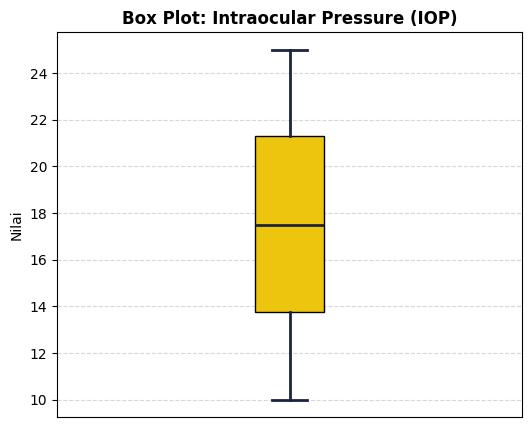

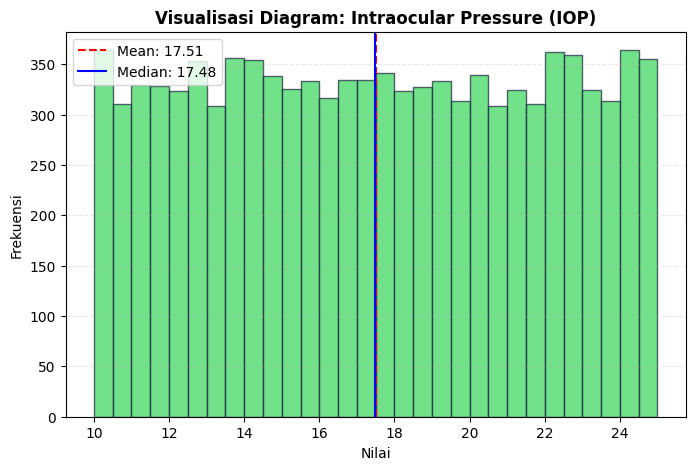

In [ ]:
visualize_boxplot(glaucoma, ['Intraocular Pressure (IOP)'])
visualize_histogram(glaucoma, ['Intraocular Pressure (IOP)'])

### Kolom Intraocular Pressure (IOP)

Berdasarkan hasil visualisasi box-plot, didapatkan bahwa kolom 'Intraocular Pressure (IOP)' memiliki karakteristik sebagai berikut:
* Nilai Minimum = 10
* Nilai Maksimum = 25
* Q1 = 13,7
* Q2 = 17,5
* Q3 = 21,3

Hasil visualisasi box-plot menunjukkan bahwa IOP pasien yang ada di dalam dataset glaucoma berada di rentang 10 mmHg hingga 25 mmHg, dengan rata-rata (median) adalah 17,5 mmHg. Tidak terdapat data outlier (titik di luar batas atas maupun batas bawah) yang terlihat dalam visualisasi box-plot.

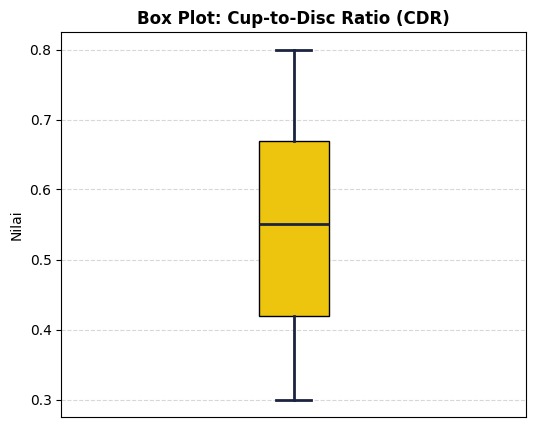

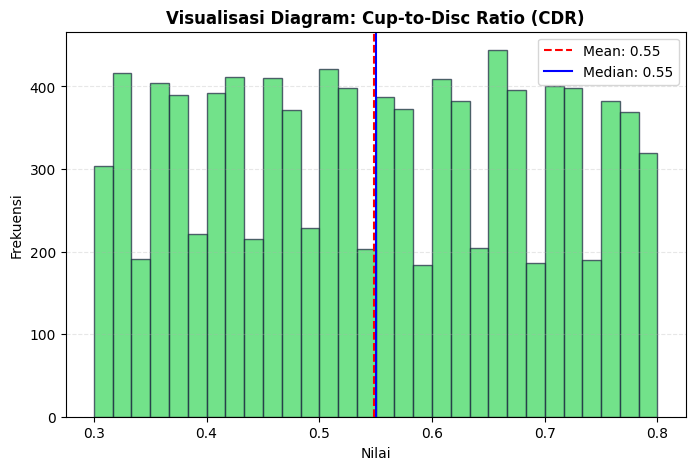

In [ ]:
visualize_boxplot(glaucoma, ['Cup-to-Disc Ratio (CDR)'])
visualize_histogram(glaucoma, ['Cup-to-Disc Ratio (CDR)'])

### Kolom Cup-to-Disc Ratio (CDR)

Berdasarkan hasil visualisasi box-plot, didapatkan bahwa kolom 'Cup-to-Disc Ratio (CDR)' memiliki karakteristik sebagai berikut:
* Nilai Minimum = 0,3
* Nilai Maksimum = 0,8
* Q1 = 0,42
* Q2 = 0,55
* Q3 = 0,67

Hasil visualisasi box-plot menunjukkan bahwa CDR pasien yang ada di dalam dataset glaucoma berada di rentang 0,3 hingga 0,8 dengan rata-rata (median) adalah 0,55. Tidak terdapat data outlier (titik di luar batas atas maupun batas bawah) yang terlihat dalam visualisasi box-plot.

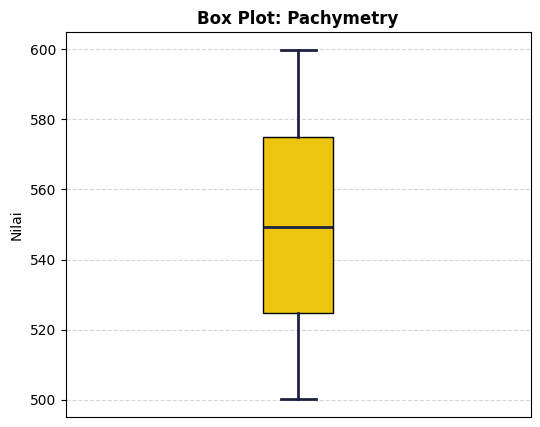

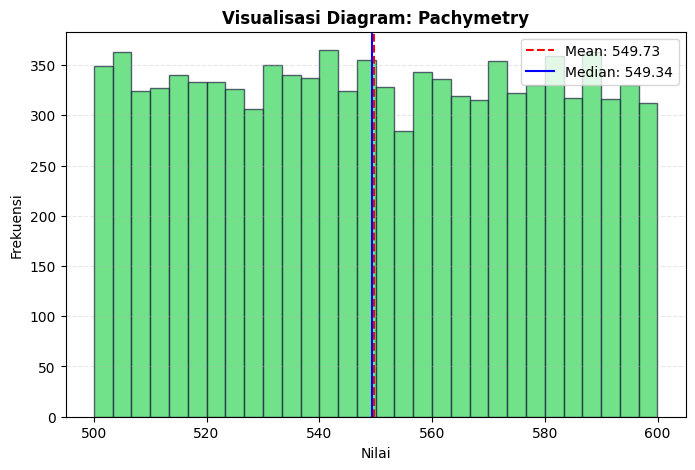

In [ ]:
visualize_boxplot(glaucoma, ['Pachymetry'])
visualize_histogram(glaucoma, ['Pachymetry'])

### Kolom Pachymetry

Berdasarkan hasil visualisasi box-plot, didapatkan bahwa kolom 'Pachymetry' memiliki karakteristik sebagai berikut:
* Nilai Minimum = 500
* Nilai Maksimum = 600
* Q1 = 524,6
* Q2 = 549,3
* Q3 = 574,9

Hasil visualisasi box-plot menunjukkan bahwa data Pachymetry pasien yang ada di dalam dataset glaucoma berada di rentang 500 hingga 600, dengan rata-rata (median) adalah 549,3. Tidak terdapat data outlier (titik di luar batas atas maupun batas bawah) yang terlihat dalam visualisasi box-plot.

Kolom Kategorikal

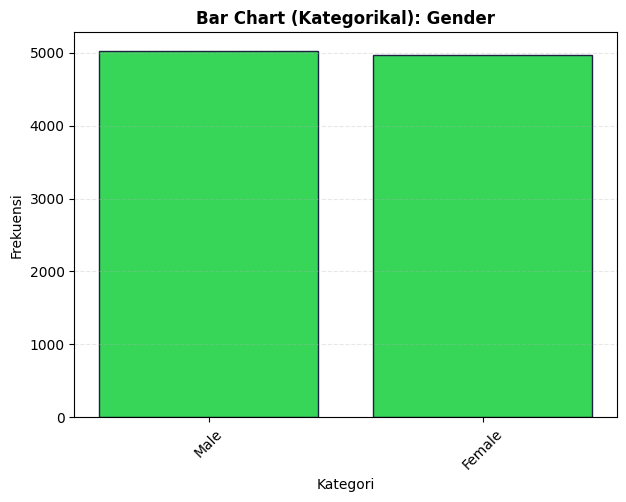

In [ ]:
visualize_categorical(glaucoma, 'Gender')

Kolom Gender
Dapat dilihat dari hasil visualisasi bahwa untuk gender male dan female itu uniform atau merata.


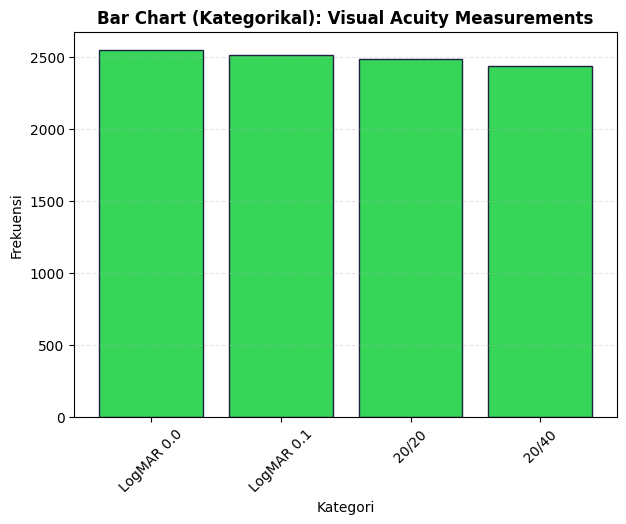

In [ ]:
visualize_categorical(glaucoma, ['Visual Acuity Measurements'])

Kolom Visual

Dapat dilihat dari visual itu memiliki data yang merata dan uniform tidak ada yang jauh berbeda.

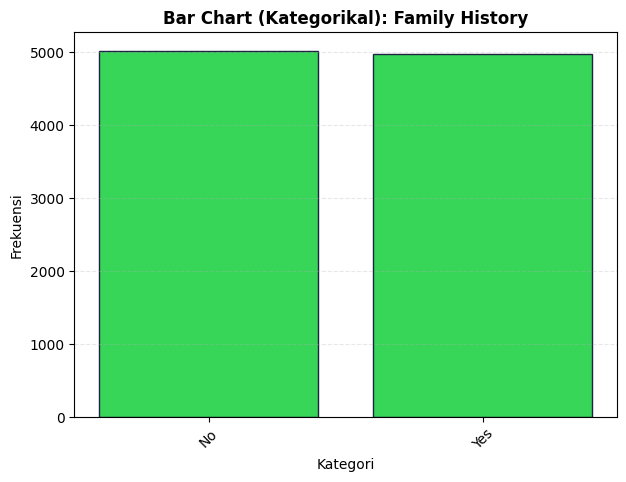

In [ ]:
visualize_categorical(glaucoma, ['Family History'])

Kolom Family History

Dapat dilihat dari visual itu memiliki data yang merata dan uniform tidak ada yang jauh berbeda.

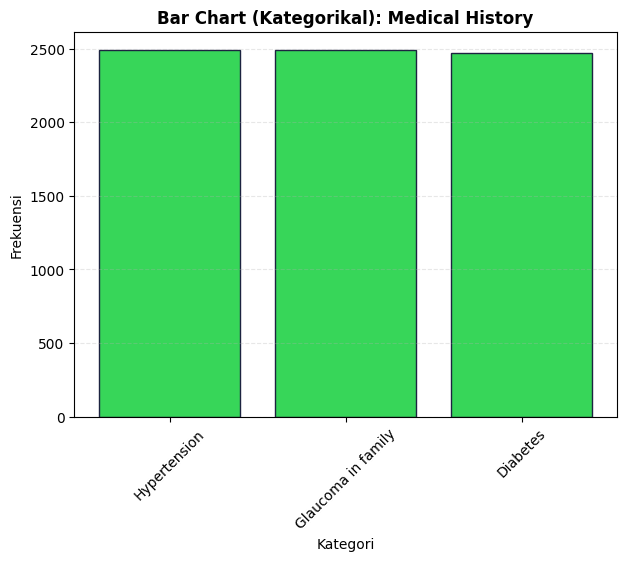

In [ ]:
visualize_categorical(glaucoma, ['Medical History'])

Kolom Medical History

Dapat dilihat dari visual itu memiliki 3 data yang merata dan uniform tidak ada yang jauh berbeda.

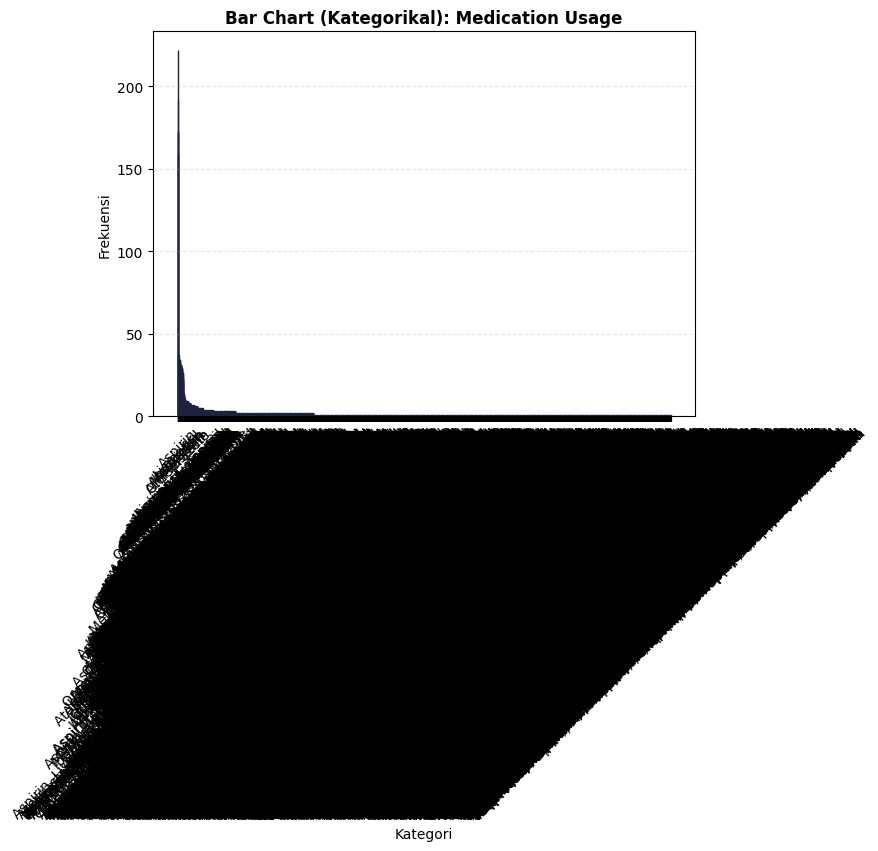

In [ ]:
visualize_categorical(glaucoma, ['Medication Usage'])

Kolom Medical Usage

Dapat dilihat dari visual itu distribusinya tidak merata dan banyak kategori dengan frekuensi yang sangat rendah sedangkan jumlah kategori sangat banyak

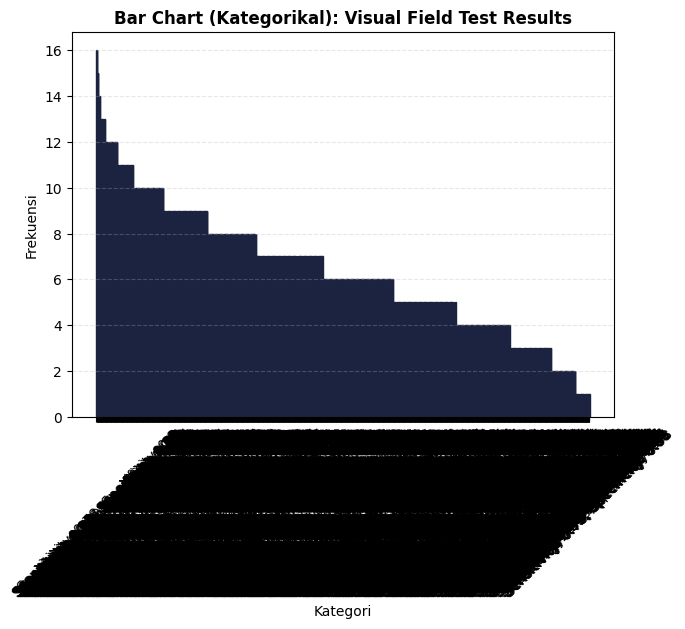

In [ ]:
visualize_categorical(glaucoma, ['Visual Field Test Results'])

Kolom Visual Field Test Results

Distribusi datanya cukup merata, dan jumlah kategori cukup banyak.

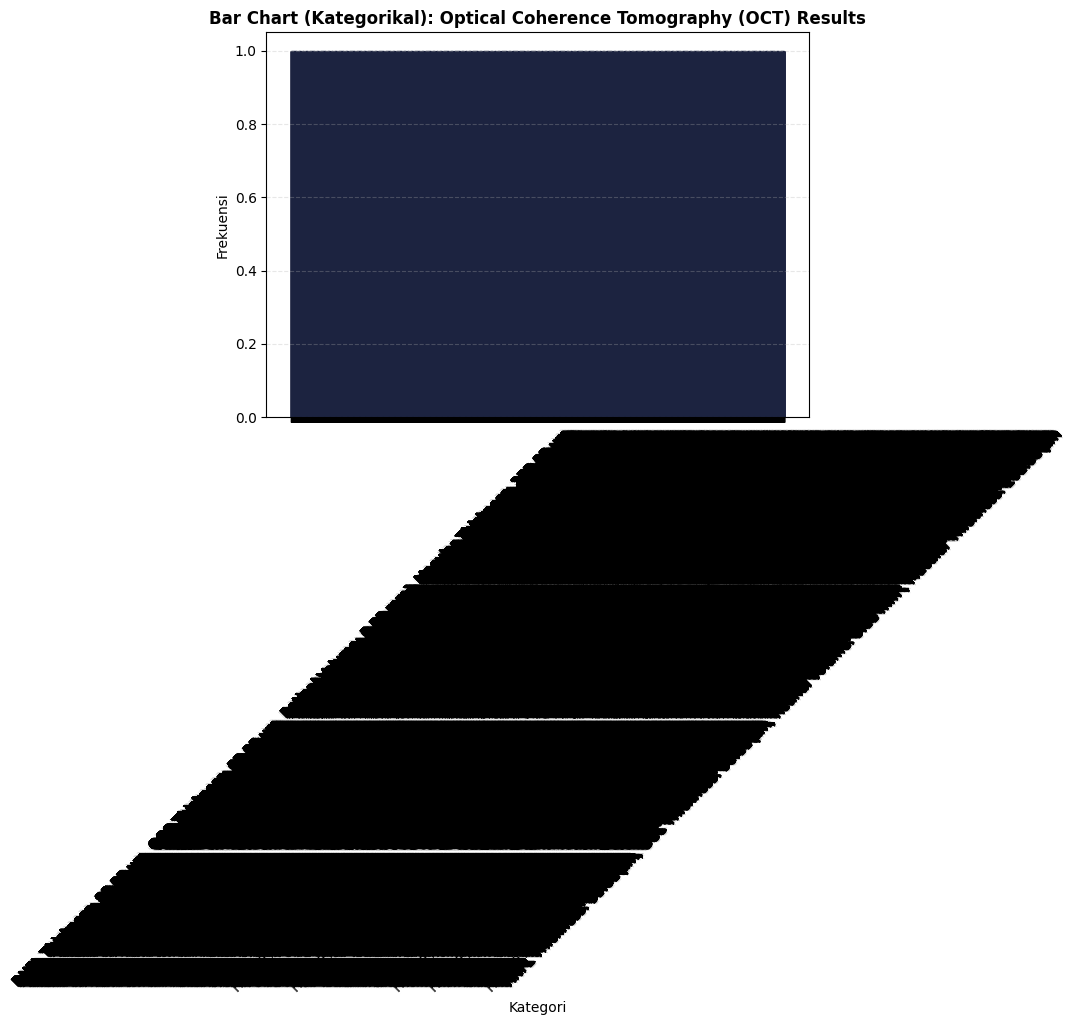

In [ ]:
visualize_categorical(glaucoma, ['Optical Coherence Tomography (OCT) Results'])

adad

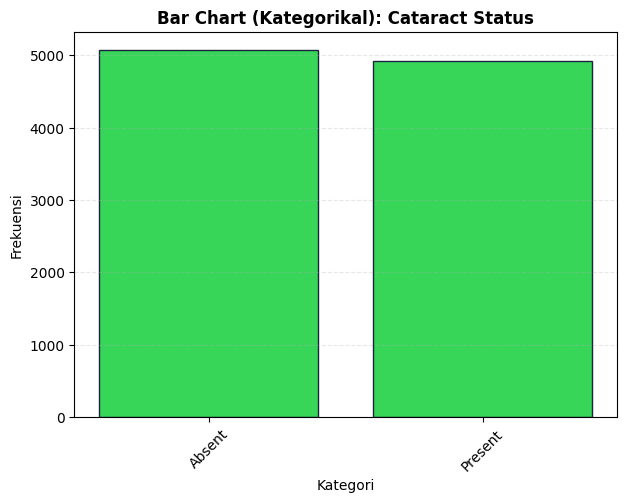

In [ ]:
visualize_categorical(glaucoma, ['Cataract Status'])

Kolom Cataract Status

Dapat dilihat dari visual itu memiliki data yang merata dan uniform tidak ada yang jauh berbeda.

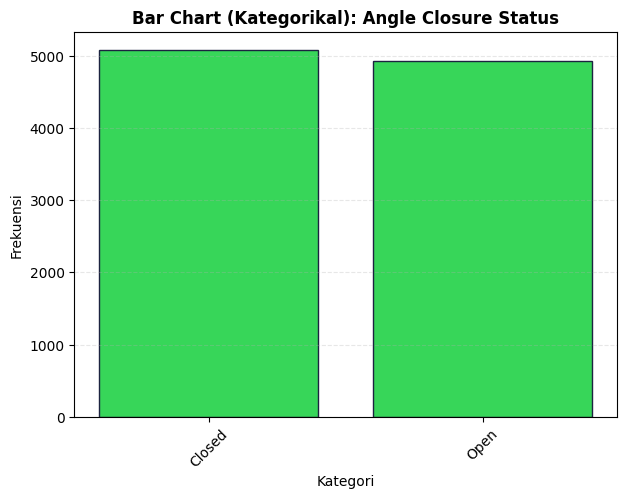

In [ ]:
visualize_categorical(glaucoma, ['Angle Closure Status'])

Kolom Angle Closure Status

Dapat dilihat dari visual itu memiliki data yang merata dan uniform tidak ada yang jauh berbeda.

In [ ]:
visualize_categorical(glaucoma, ['Visual Symptoms'])

Kolom Visual Symptoms

Distribusi berbeda dan banyak kategori


In [ ]:
visualize_categorical(glaucoma, ['Diagnosis'])

Kolom Diagnosis

Dapat dilihat dari visual itu memiliki data yang merata dan uniform tidak ada yang jauh berbeda.

In [ ]:
visualize_categorical(glaucoma, ['Glaucoma Type'])

Kolom Glaucoma Type

Distribusinya merata, tidak ada tipe glaucoma yang dominan

## Nomor 4
Menentukan distribusi setiap kolom numerik menggunakan hasil visualisasi histogram. Apakah kolom tersebut berdistribusi normal? Jika bukan, terdistribusi seperti apa kolom tersebut?

In [ ]:

visualize_histogram(glaucoma, ['Age'])
visualize_histogram(glaucoma, ['Intraocular Pressure (IOP)'])
visualize_histogram(glaucoma, ['Cup-to-Disc Ratio (CDR)'])
visualize_histogram(glaucoma, ['Pachymetry'])


Berdasarkan diagram histogram dari seluruh kolom dengan tipe data numerik, dapat terlihat bahwa diagram tidak terdistribusi normal. Diagram-diagram histogram ini terdistribusi seragam (Uniform). Karena bisa dilihat bahwa ketinggian dari batang-batang histogramnya meskipun bervariasi tingginya memiliki ketinggian yang kurang lebih sama satu sama lain, selain itu juga tidak terlihat misalnya puncak atau batang yang jauh lebih tinggi dibandingkan batang histogram lainnya. Selain dari visualisasi tersebut, jika memperhatikan data mean dan median dari setiap visualisasi histogram setiap kolom data numerik, didapatkan bahwa mean dan mediannya dari setiap kolom data itu hampir sama, sehingga menandakan dataset ini seimbang.

# Soal Spesifik Dataset

Enam Langkah Testing:

1. Tentukan Hipotesis nol (H0: θ = θ0), dimana θ bisa berupa μ, σ2, p, atau data lain berdistribusi tertentu (normal, binomial, dsc.).
2. Pilih hipotesis alternatif H1 salah dari dari θ > θ0, θ < θ0, atau θ ≠ θ0.
3. Tentukan tingkat signifikan α.
4. Tentukan uji statistik yang sesuai dan tentukan daerah kritis.
5. Hitung nilai uji statistik dari data sample. Hitung p-value sesuai dengan uji statistik yang digunakan.
6. Ambil keputusan dengan TOLAK H0 jika nilai uji terletak di daerah kritis atau dengan tes signifikan, TOLAK H0 jika p-value lebih kecil dibanding tingkat signifikansi α yang diinginkan

## Nomor 5 : Hipotesis 1 Sampel

1. Periksalah apakah rata-rata tekanan intraokular pasien lebih dari 21 mmHg? (21 mmHg adalah batas normal IOP)
2. Periksalah apakah rata-rata Cup-to-Disc Ratio (CDR) tidak sama dengan 0.3? (0.3 adalah nilai CDR normal)
3. Apakah proporsi pasien dengan riwayat keluarga glaukoma tidak sama dengan 25% dari total dataset?
4. Apakah proporsi pasien dengan tekanan intraokular (IOP) lebih dari 21 mmHg tidak sama dengan 40% dari total dataset?


In [ ]:
def hitung_integral(f, a, b, n=1200):
    if n % 2 == 1:
        n += 1
    h = (b - a) / n
    total = f(a) + f(b)

    for i in range(1, n):
        x = a + i * h
        total += f(x) * (4 if i % 2 else 2)

    return total * h / 3


def t_pdf(t, df):
    C = math.exp(math.lgamma((df+1)/2) - math.lgamma(df/2)) / math.sqrt(df * math.pi)
    return C * (1 + (t**2)/df) ** (-(df+1)/2)


def t_cdf(t, df):
    if t == 0:
        return 0.5
    if t > 0:
        return 0.5 + hitung_integral(lambda x: t_pdf(x, df), 0, t)
    else:
        return 0.5 - hitung_integral(lambda x: t_pdf(x, df), 0, -t)


def t_ppf(p, df, tol=1e-6, max_iter=70):
    t = 0.0
    for _ in range(max_iter):
        f = t_cdf(t, df) - p
        fp = t_pdf(t, df)
        t_new = t - f / fp
        if abs(t_new - t) < tol:
            return t_new
        t = t_new
    return t


def z_pdf(z):
    return math.exp(-z*z/2) / math.sqrt(2*math.pi)

def z_cdf(z):
    return 0.5 * (1 + math.erf(z/math.sqrt(2)))

def z_ppf(p, tol=1e-6):
    z = 0.0
    for _ in range(70):
        f = z_cdf(z) - p
        fp = z_pdf(z)
        z_new = z - f/fp
        if abs(z_new - z) < tol:
            return z_new
        z = z_new
    return z


In [ ]:
def mean_manual(data):
    return sum(data) / len(data)

def variance_manual(data):
    mean = mean_manual(data)
    return sum((x - mean)**2 for x in data) / (len(data)-1)


In [ ]:
def t_test(data, mu0, alpha=0.05, tail="two-tailed"):
    n = len(data)
    xbar = mean_manual(data)
    s = math.sqrt(variance_manual(data))
    df = n - 1

    t_stat = (xbar - mu0) / (s / math.sqrt(n))

    # p-value
    if tail == "right":
        p = 1 - t_cdf(t_stat, df)
        tcrit = t_ppf(1 - alpha, df)

    elif tail == "left":
        p = t_cdf(t_stat, df)
        tcrit = t_ppf(alpha, df)

    else:
        p = 2 * (1 - t_cdf(abs(t_stat), df))
        tcrit_low = t_ppf(alpha/2, df)
        tcrit_high = t_ppf(1 - alpha/2, df)

    return {
        "n": n,
        "mean": xbar,
        "sd": s,
        "t_stat": t_stat,
        "p_value": p,
        "df": df,
        "tcrit_low": tcrit_low if tail=="two-tailed" else None,
        "tcrit_high": tcrit_high if tail=="two-tailed" else None,
        "tcrit": tcrit if tail!="two-tailed" else None
    }


In [ ]:
def proportion_test(success, n, p0, alpha=0.05, tail="two-tailed"):
    phat = success / n
    z_stat = (phat - p0) / math.sqrt(p0*(1-p0)/n)

    if tail == "right":
        p = 1 - z_cdf(z_stat)
        zcrit = z_ppf(1 - alpha)

    elif tail == "left":
        p = z_cdf(z_stat)
        zcrit = z_ppf(alpha)

    else:
        p = 2 * (1 - z_cdf(abs(z_stat)))
        zcrit_low = z_ppf(alpha/2)
        zcrit_high = z_ppf(1 - alpha/2)

    return {
        "n": n,
        "phat": phat,
        "z_stat": z_stat,
        "p_value": p,
        "zcrit": zcrit if tail!="two-tailed" else None,
        "zcrit_low": zcrit_low if tail=="two-tailed" else None,
        "zcrit_high": zcrit_high if tail=="two-tailed" else None
    }


In [ ]:
def langkah(data, mu0, alpha, tail):

    # Langkah 1
    print("\nLangkah 1: Tentukan Hipotesis Nol (H0)")
    if tail == "right":
        print(f"H0: μ ≤ {mu0}")
    elif tail == "left":
        print(f"H0: μ ≥ {mu0}")
    else:
        print(f"H0: μ = {mu0}")

    # Langkah 2
    print("\nLangkah 2: Tentukan Hipotesis Alternatif (H1)")
    if tail == "right":
        print(f"H1: μ > {mu0}")
    elif tail == "left":
        print(f"H1: μ < {mu0}")
    else:
        print(f"H1: μ ≠ {mu0}")

    # Langkah 3
    print("\nLangkah 3: Tentukan Tingkat Signifikansi")
    print(f"α = {alpha}")

    hasil = t_test(data, mu0, alpha, tail)

    # Langkah 4
    print("\nLangkah 4: Tentukan Uji Statistik dan Daerah Kritis")
    print("Uji Statistik: t-test satu sampel")
    if tail == "right":
        print(f"Daerah kritis: t > {hasil['tcrit']:.4f}")
    elif tail == "left":
        print(f"Daerah kritis: t < {hasil['tcrit']:.4f}")
    else:
        print(f"Daerah kritis: t < {hasil['tcrit_low']:.4f} atau t > {hasil['tcrit_high']:.4f}")

    # Langkah 5
    print("\nLangkah 5: Hitung nilai uji statistik dan p-value")
    print(f"t-stat: {hasil['t_stat']:.4f}")
    print(f"p-value: {hasil['p_value']:.4f}")

    # Langkah 6
    print("\nLangkah 6: Keputusan Akhir")

    reject = False
    if tail == "right":
        reject = hasil["t_stat"] > hasil["tcrit"]
    elif tail == "left":
        reject = hasil["t_stat"] < hasil["tcrit"]
    else:
        reject = hasil["t_stat"] < hasil["tcrit_low"] or hasil["t_stat"] > hasil["tcrit_high"]

    if reject or hasil["p_value"] < alpha:
        print("Tolak H0 karena nilai uji masuk daerah kritis ATAU p-value < α")
    else:
        print("Gagal tolak H0 karena nilai uji di luar daerah kritis DAN p-value ≥ α")


In [ ]:
def langkah_proporsi(success, n, p0, alpha, tail):

    # Langkah 1
    print("\nLangkah 1: Tentukan Hipotesis Nol (H0)")
    if tail == "right":
        print(f"H0: p ≤ {p0}")
    elif tail == "left":
        print(f"H0: p ≥ {p0}")
    else:
        print(f"H0: p = {p0}")

    # Langkah 2
    print("\nLangkah 2: Tentukan Hipotesis Alternatif (H1)")
    if tail == "right":
        print(f"H1: p > {p0}")
    elif tail == "left":
        print(f"H1: p < {p0}")
    else:
        print(f"H1: p ≠ {p0}")

    # Langkah 3
    print("\nLangkah 3: Tentukan Tingkat Signifikansi")
    print(f"α = {alpha}")

    hasil = proportion_test(success, n, p0, alpha, tail)

    # Langkah 4
    print("\nLangkah 4: Tentukan Uji Statistik dan Daerah Kritis")
    print("Uji Statistik: z-test proporsi satu sampel")
    if tail == "right":
        print(f"Daerah kritis: z > {hasil['zcrit']:.4f}")
    elif tail == "left":
        print(f"Daerah kritis: z < {hasil['zcrit']:.4f}")
    else:
        print(f"Daerah kritis: z < {hasil['zcrit_low']:.4f} atau z > {hasil['zcrit_high']:.4f}")

    # Langkah 5
    print("\nLangkah 5: Hitung nilai uji statistik dan p-value")
    print(f"Proporsi sampel (p̂): {hasil['phat']:.4f}")
    print(f"z-stat: {hasil['z_stat']:.4f}")
    print(f"p-value: {hasil['p_value']:.4f}")

    # Langkah 6
    print("\nLangkah 6: Keputusan Akhir")
    if hasil["p_value"] < alpha:
        print(f"Tolak H0 karena p-value ({hasil['p_value']:.4f}) < α ({alpha})")
    else:
        print(f"Gagal tolak H0 karena p-value ({hasil['p_value']:.4f}) ≥ α ({alpha})")

### 5.1
Periksalah apakah rata-rata tekanan intraokular pasien lebih dari 21 mmHg? (21 mmHg adalah batas normal IOP)

In [ ]:
iop_data = glaucoma["Intraocular Pressure (IOP)"].tolist()
langkah(
    data=iop_data,
    mu0=21,
    alpha=0.05,
    tail="right",
)

### 5.2
Periksalah apakah rata-rata Cup-to-Disc Ratio (CDR) tidak sama dengan 0.3? (0.3 adalah nilai CDR normal)

In [ ]:
iop_data = glaucoma["Cup-to-Disc Ratio (CDR)"].tolist()

langkah(
    data=iop_data,
    mu0=0.3,
    alpha=0.05,
    tail="two-tailed",
)

### 5.3
Apakah proporsi pasien dengan riwayat keluarga glaukoma tidak sama dengan 25% dari total dataset?

In [ ]:
fh_data = glaucoma["Family History"].dropna().tolist()
success = sum(1 for x in fh_data if str(x).lower() == "yes")
n = len(fh_data)

langkah_proporsi(
    success=success,
    n=n,
    p0=0.25,
    alpha=0.05,
    tail="two-tailed",
)

### 5.4
Apakah proporsi pasien dengan tekanan intraokular (IOP) lebih dari 21 mmHg tidak sama dengan 40% dari total dataset?

In [ ]:
iop_data = glaucoma["Intraocular Pressure (IOP)"].dropna().tolist()
success = sum(1 for x in iop_data if x > 21)
n = len(iop_data)

langkah_proporsi(
    success=success,
    n=n,
    p0=0.40,
    alpha=0.05,
    tail="two-tailed",
)

## Nomor 6 : Hipotesis 2 Sampel
1. Periksalah apakah rata-rata IOP pada paruh awal sama dengan paruh akhir?
2. Apakah rata-rata CDR pada paruh awal lebih besar 0.1 unit daripada paruh akhir?
3. Periksalah apakah variansi IOP sama pada kedua paruh dataset?
4. Apakah proporsi diagnosis positif pada paruh awal lebih besar daripada paruh akhir?

In [ ]:
import math

def simpson_integrate(f, a, b, n=1000):
    if n % 2 == 1:
        n += 1
    h = (b - a) / n
    s = f(a) + f(b)
    for i in range(1, n):
        x = a + i * h
        s += (4 if i % 2 else 2) * f(x)
    return s * h / 3.0

def normal_pdf(z):
    return (1.0 / math.sqrt(2.0 * math.pi)) * math.exp(-0.5 * z * z)

def normal_cdf(z):
    if z < -10:
        return 0.0
    if z > 10:
        return 1.0
    return simpson_integrate(normal_pdf, -10.0, z, n=2000)

def t_pdf(x, v):
    log_c = math.lgamma((v + 1.0) / 2.0) - math.lgamma(v / 2.0) - 0.5 * math.log(v * math.pi)
    log_body = -((v + 1.0) / 2.0) * math.log(1.0 + (x * x) / v)
    return math.exp(log_c + log_body)

def t_cdf(t, v):
    if t == 0:
        return 0.5
    upper = abs(t)
    seg = max(400, min(4000, int(upper * 200)))
    area = simpson_integrate(lambda x: t_pdf(x, v), 0.0, upper, n=seg)
    return 0.5 + area if t > 0 else 0.5 - area

def f_pdf(x, d1, d2):
    if x <= 0:
        return 0.0
    a = d1 / 2.0
    b = d2 / 2.0
    log_num = math.log(d1) * a + math.log(d2) * b + (a - 1.0) * math.log(x)
    log_den = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b) + (a + b) * math.log(d1 * x + d2)
    return math.exp(log_num - log_den)

def f_cdf(x, d1, d2):
    if x <= 0:
        return 0.0
    seg = max(600, min(6000, int((x + 1) * 400)))
    area = simpson_integrate(lambda t: f_pdf(t, d1, d2), 0.0, x, n=seg)
    return min(1.0, max(0.0, area))


def t_test_two_sample(data1, data2, diff0=0.0, tail='two', equal_var=False):
    n1, n2 = len(data1), len(data2)
    m1, m2 = mean_manual(data1), mean_manual(data2)
    s1_sq, s2_sq = variansi_manual(data1), variansi_manual(data2)
    if equal_var:
        sp_sq = ((n1 - 1) * s1_sq + (n2 - 1) * s2_sq) / (n1 + n2 - 2)
        se = math.sqrt(sp_sq * (1.0 / n1 + 1.0 / n2))
        df = n1 + n2 - 2
    else:
        se_sq = s1_sq / n1 + s2_sq / n2
        se = math.sqrt(se_sq)
        df = se_sq ** 2 / ((s1_sq ** 2) / (n1 ** 2 * (n1 - 1)) + (s2_sq ** 2) / (n2 ** 2 * (n2 - 1)))
    t_stat = (m1 - m2 - diff0) / se
    if tail == 'right':
        p_val = 1.0 - t_cdf(t_stat, df)
    elif tail == 'left':
        p_val = t_cdf(t_stat, df)
    else:
        p_val = 2.0 * min(t_cdf(abs(t_stat), df), 1.0 - t_cdf(abs(t_stat), df))
    return t_stat, df, p_val


### 6.1
Periksalah apakah rata-rata IOP pada paruh awal sama dengan paruh akhir?

In [ ]:

alpha = 0.05
mid = len(glaucoma) // 2
first_half = glaucoma.iloc[:mid]
second_half = glaucoma.iloc[mid:]
iop_col = 'Intraocular Pressure (IOP)'

iop_first = list(first_half[iop_col])
iop_second = list(second_half[iop_col])

t_stat_61, df_61, p_val_61 = t_test_two_sample(
    iop_first,
    iop_second,
    diff0=0.0,
    tail='two',
    equal_var=False
)

print('Langkah Pertama')
print('Tentukan Hipotesis nol (H0):')
print('H0: μ1 - μ2 = 0 (rata-rata IOP paruh awal sama dengan paruh akhir)')

print('Langkah Kedua')
print('Pilih hipotesis alternatif (H1):')
print('H1: μ1 - μ2 ≠ 0 (rata-rata IOP paruh awal berbeda dengan paruh akhir)')

print('Langkah Ketiga')
print('Tentukan tingkat signifikansi:')
print(f'α = {alpha}')

print('Langkah Keempat')
print('Menentukan uji statistik dan daerah kritis:')
print('- Uji Statistik : uji t dua-sampel (Welch) untuk perbedaan rata-rata')
print('- Statistik uji : t = (x̄1 - x̄2 - 0) / SE, dengan df ≈ derajat bebas Welch')
print('- Daerah kritis : Tolak H0 jika |t| > t_(α/2; df) (uji dua sisi)')

print('Langkah Kelima')
print('Hitung nilai statistik uji dan p-value dari data sampel:')
print(f't hitung   = {t_stat_61:.4f}')
print(f'derajat bebas (df) ≈ {df_61:.2f}')
print(f'p-value    = {p_val_61:.6f}')

print('Langkah Keenam')
print('Ambil keputusan berdasarkan p-value:')
if p_val_61 < alpha:
    print(f'Karena p-value ({p_val_61:.6f}) < α ({alpha}), maka TOLAK H0.')
    print('Kesimpulan: rata-rata IOP paruh awal TIDAK sama dengan rata-rata IOP paruh akhir.')
else:
    print(f'Karena p-value ({p_val_61:.6f}) ≥ α ({alpha}), maka GAGAL MENOLAK H0.')
    print('Kesimpulan: tidak cukup bukti untuk menyatakan rata-rata IOP paruh awal berbeda dari paruh akhir.')


### 6.2
Apakah rata-rata CDR pada paruh awal lebih besar 0.1 unit daripada paruh akhir?

In [ ]:

alpha = 0.05
delta = 0.1
mid = len(glaucoma) // 2
first_half = glaucoma.iloc[:mid]
second_half = glaucoma.iloc[mid:]
cdr_col = 'Cup-to-Disc Ratio (CDR)'

cdr_first = list(first_half[cdr_col])
cdr_second = list(second_half[cdr_col])

t_stat_62, df_62, p_val_62 = t_test_two_sample(
    cdr_first,
    cdr_second,
    diff0=delta,
    tail='right',
    equal_var=False
)
mean_diff_62 = mean_manual(cdr_first) - mean_manual(cdr_second)

print('Langkah Pertama')
print('Tentukan Hipotesis nol (H0):')
print('H0: μ1 - μ2 = 0.1 (CDR awal = CDR akhir + 0.1)')

print('Langkah Kedua')
print('Pilih hipotesis alternatif (H1):')
print('H1: μ1 - μ2 > 0.1 (CDR awal lebih besar 0.1 unit)')

print('Langkah Ketiga')
print(f'α = {alpha}')

print('Langkah Keempat')
print('Uji t dua-sampel (Welch), sisi kanan, delta = 0.1')

print('Langkah Kelima')
print(f't hitung   = {t_stat_62:.4f}')
print(f'derajat bebas (df) ≈ {df_62:.2f}')
print(f'p-value    = {p_val_62:.6f}')
print(f'selisih rata-rata sampel = {mean_diff_62:.4f}')

print('Langkah Keenam')
if p_val_62 < alpha:
    print(f'Karena p-value ({p_val_62:.6f}) < α ({alpha}), maka TOLAK H0.')
    print('Kesimpulan: rata-rata CDR paruh awal lebih besar >0.1 unit daripada paruh akhir.')
else:
    print(f'Karena p-value ({p_val_62:.6f}) ≥ α ({alpha}), maka GAGAL MENOLAK H0.')
    print('Kesimpulan: belum cukup bukti bahwa selisih rata-rata CDR > 0.1 unit.')


### 6.3
Periksalah apakah variansi IOP sama pada kedua paruh dataset?

In [ ]:


alpha = 0.05
mid = len(glaucoma) // 2
first_half = glaucoma.iloc[:mid]
second_half = glaucoma.iloc[mid:]
iop_col = 'Intraocular Pressure (IOP)'

iop_first = list(first_half[iop_col])
iop_second = list(second_half[iop_col])

def f_test_variance_manual(data1, data2):
    var1 = variansi_manual(data1)
    var2 = variansi_manual(data2)
    n1, n2 = len(data1), len(data2)
    if var1 >= var2:
        F = var1 / var2
        df1, df2 = n1 - 1, n2 - 1
    else:
        F = var2 / var1
        df1, df2 = n2 - 1, n1 - 1
    cdf_val = f_cdf(F, df1, df2)
    p_val = 2 * min(cdf_val, 1 - cdf_val)
    return F, df1, df2, p_val, var1, var2

F_63, df1_63, df2_63, p_val_63, var1_63, var2_63 = f_test_variance_manual(iop_first, iop_second)

print('Langkah Pertama')
print('H0: σ1^2 = σ2^2 (variansi IOP sama)')
print('H1: σ1^2 ≠ σ2^2')

print('Langkah Ketiga')
print(f'α = {alpha}')

print('Langkah Keempat')
print('Uji F dua sisi, gunakan var lebih besar di pembilang')

print('Langkah Kelima')
print(f'F hitung   = {F_63:.4f}')
print(f'df1 = {df1_63}, df2 = {df2_63}')
print(f'p-value    = {p_val_63:.6f}')
print(f'var_awal = {var1_63:.4f}, var_akhir = {var2_63:.4f}')

print('Langkah Keenam')
if p_val_63 < alpha:
    print(f'Karena p-value ({p_val_63:.6f}) < α ({alpha}), maka TOLAK H0.')
    print('Kesimpulan: variansi IOP berbeda antara paruh awal dan akhir.')
else:
    print(f'Karena p-value ({p_val_63:.6f}) ≥ α ({alpha}), maka GAGAL MENOLAK H0.')
    print('Kesimpulan: tidak cukup bukti bahwa variansi IOP berbeda.')


### 6.4
Apakah proporsi diagnosis positif pada paruh awal lebih besar daripada paruh akhir?


In [ ]:
alpha = 0.05
mid = len(glaucoma) // 2
first_half = glaucoma.iloc[:mid]
second_half = glaucoma.iloc[mid:]
diag_col = 'Diagnosis'

def z_test_two_proportion(x1, n1, x2, n2, tail='right'):
    p1 = x1 / n1
    p2 = x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = math.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    if tail == 'right':
        p_val = 1 - normal_cdf(z)
    elif tail == 'left':
        p_val = normal_cdf(z)
    else:
        p_val = 2 * min(normal_cdf(z), 1 - normal_cdf(z))
    return z, p_val, p1, p2, p_pool

pos_first = (first_half[diag_col] != 'No Glaucoma').sum()
pos_second = (second_half[diag_col] != 'No Glaucoma').sum()
n1_64, n2_64 = len(first_half), len(second_half)

z_64, p_val_64, p1_64, p2_64, p_pool_64 = z_test_two_proportion(pos_first, n1_64, pos_second, n2_64, tail='right')

print('Langkah Pertama')
print('H0: p1 - p2 = 0 (proporsi sama)')
print('H1: p1 - p2 > 0 (proporsi awal lebih besar)')

print('Langkah Ketiga')
print(f'α = {alpha}')

print('Langkah Keempat')
print('Uji z dua proporsi, satu sisi kanan')

print('Langkah Kelima')
print(f'x1 = {pos_first}, n1 = {n1_64}, x2 = {pos_second}, n2 = {n2_64}')
print(f'z hitung   = {z_64:.4f}')
print(f'p-value    = {p_val_64:.6f}')
print(f'p1 = {p1_64:.4f}, p2 = {p2_64:.4f}, p_pool = {p_pool_64:.4f}')

print('Langkah Keenam')
if p_val_64 < alpha:
    print(f'Karena p-value ({p_val_64:.6f}) < α ({alpha}), maka TOLAK H0.')
    print('Kesimpulan: proporsi diagnosis positif paruh awal lebih besar daripada paruh akhir.')
else:
    print(f'Karena p-value ({p_val_64:.6f}) ≥ α ({alpha}), maka GAGAL MENOLAK H0.')
    print('Kesimpulan: tidak cukup bukti proporsi diagnosis positif paruh awal lebih besar.')


Link : https://drive.google.com/drive/folders/1TE-qrUb6FbR9buSvWCksanGLJVwFRTtp?usp=sharing